# Lab 8. Tree-Based-Methods

## Imports

In [16]:
from ISLP import load_data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

## Zad 10.

In [3]:
data = load_data("Hitters")
data.shape

(322, 20)

In [4]:
data.isna().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [5]:
data.dropna(subset=['Salary'],axis=0,inplace=True)
data.shape

(263, 20)

In [6]:
data['Salary'] = np.log(data['Salary'])
data['Salary']

1      6.163315
2      6.173786
3      6.214608
4      4.516339
5      6.620073
         ...   
317    6.551080
318    6.774224
319    5.953243
320    6.866933
321    6.907755
Name: Salary, Length: 263, dtype: float64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      263 non-null    int64   
 1   Hits       263 non-null    int64   
 2   HmRun      263 non-null    int64   
 3   Runs       263 non-null    int64   
 4   RBI        263 non-null    int64   
 5   Walks      263 non-null    int64   
 6   Years      263 non-null    int64   
 7   CAtBat     263 non-null    int64   
 8   CHits      263 non-null    int64   
 9   CHmRun     263 non-null    int64   
 10  CRuns      263 non-null    int64   
 11  CRBI       263 non-null    int64   
 12  CWalks     263 non-null    int64   
 13  League     263 non-null    category
 14  Division   263 non-null    category
 15  PutOuts    263 non-null    int64   
 16  Assists    263 non-null    int64   
 17  Errors     263 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  263 non-null    categor

In [8]:
split_idx = 200
train_data = data[:split_idx]
test_data = data[split_idx:]

train_data.shape,test_data.shape

((200, 20), (63, 20))

In [9]:
X_train = pd.get_dummies(train_data.drop(columns=['Salary']),drop_first=True)
y_train = train_data['Salary']
X_test = pd.get_dummies(test_data.drop(columns=['Salary']),drop_first=True)
y_test = test_data['Salary']

In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 248
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   AtBat        200 non-null    int64
 1   Hits         200 non-null    int64
 2   HmRun        200 non-null    int64
 3   Runs         200 non-null    int64
 4   RBI          200 non-null    int64
 5   Walks        200 non-null    int64
 6   Years        200 non-null    int64
 7   CAtBat       200 non-null    int64
 8   CHits        200 non-null    int64
 9   CHmRun       200 non-null    int64
 10  CRuns        200 non-null    int64
 11  CRBI         200 non-null    int64
 12  CWalks       200 non-null    int64
 13  PutOuts      200 non-null    int64
 14  Assists      200 non-null    int64
 15  Errors       200 non-null    int64
 16  League_N     200 non-null    bool 
 17  Division_W   200 non-null    bool 
 18  NewLeague_N  200 non-null    bool 
dtypes: bool(3), int64(16)
memory usage: 27.1 KB


In [11]:
n_estimators = 1000
lambda_values = [0.001,0.01,0.1,0.5]

test_mse = []
train_mse = []

for lam in lambda_values:
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=lam
    )

    model.fit(X_train,y_train)

    y_train_hat = model.predict(X_train)
    y_test_hat = model.predict(X_test)

    rss_train = np.sum((y_train - y_train_hat)**2)
    mse_train = rss_train / len(y_train)

    rss_test = np.sum((y_test - y_test_hat)**2)
    mse_test = rss_test / len(y_test)

    train_mse.append(mse_train)
    test_mse.append(mse_test)

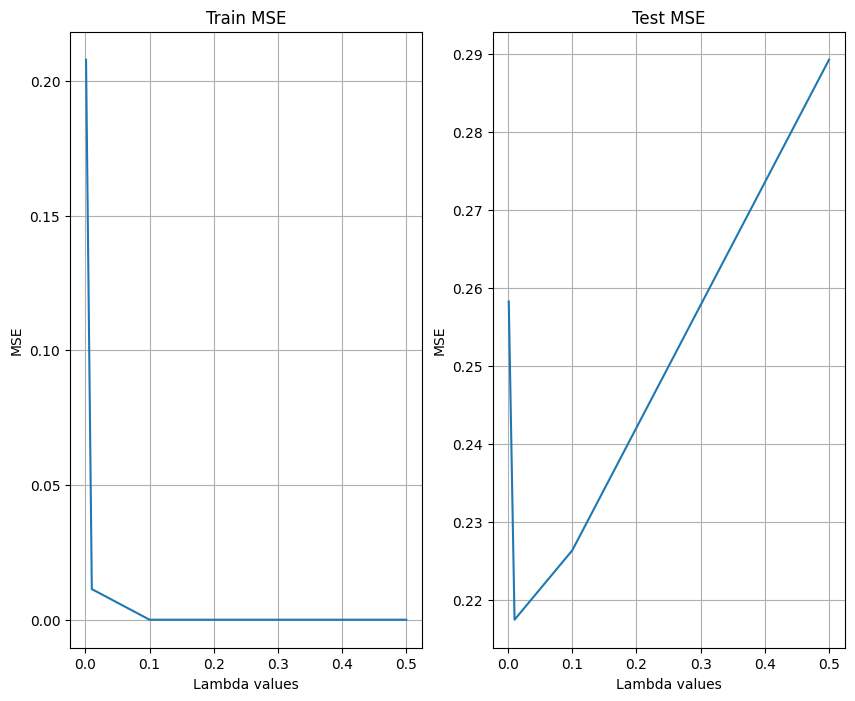

In [12]:
figure,axes = plt.subplots(1,2,figsize=(10,8))
axes[0].plot(lambda_values,train_mse)
axes[0].set_title("Train MSE")
axes[0].set_xlabel("Lambda values")
axes[0].set_ylabel("MSE")
axes[0].grid(True)

axes[1].plot(lambda_values,test_mse)
axes[1].set_title("Test MSE")
axes[1].set_xlabel("Lambda values")
axes[1].set_ylabel("MSE")
axes[1].grid(True)

plt.show()

## Zad 11.

In [13]:
data = load_data("Caravan")
data

,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,No
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,No
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,No
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5817,36,1,1,2,8,0,6,1,2,1,...,0,0,0,1,0,0,0,0,0,No
5818,35,1,4,4,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,No
5819,33,1,3,4,8,0,6,0,3,5,...,0,0,0,1,0,0,0,0,0,Yes
5820,34,1,3,2,8,0,7,0,2,7,...,0,0,0,0,0,0,0,0,0,No


In [14]:
X = data.drop(columns=["Purchase"])
y = data['Purchase']

split_idx = 1000

X_train,X_test = X[:split_idx],X[split_idx:]
y_train,y_test = y[:split_idx],y[split_idx:]

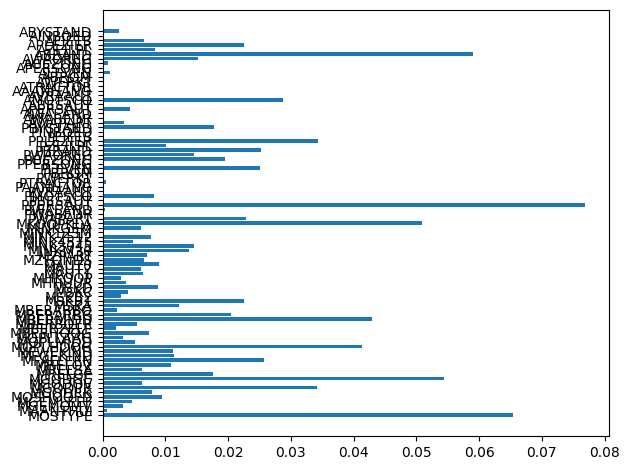

In [ ]:
model = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.01
)

model.fit(X_train,y_train)
feature_names = X_train.columns

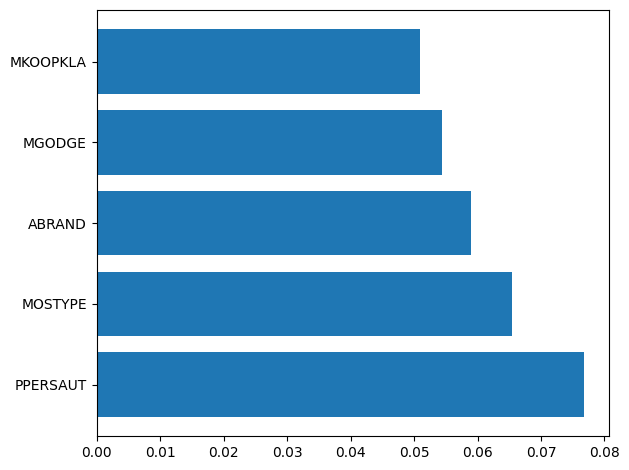

In [26]:
df = pd.DataFrame({'feature': feature_names, 'importance':model.feature_importances_})

df.sort_values('importance',ascending=False,inplace=True)
plt.barh(df['feature'].head(),df['importance'].head())
plt.tight_layout()
plt.show()

In [31]:
probs = model.predict_proba(X_test)[:,1]

print(probs[:10])
threshold = 0.2

preds = np.where(probs > threshold, "Yes", "No")
preds

[0.02395581 0.04565972 0.01558534 0.01701924 0.12118462 0.10689115
 0.02415851 0.14123389 0.06751741 0.02010679]


array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype='<U3')

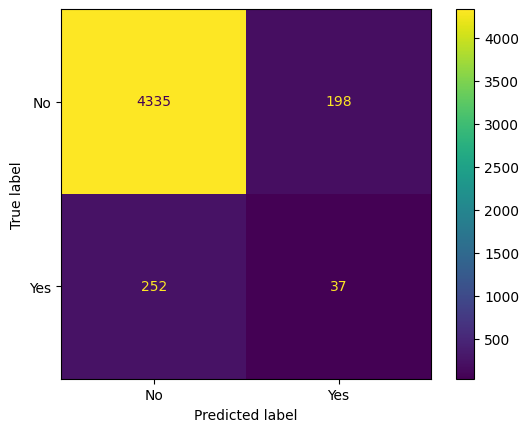

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,preds,labels=["No","Yes"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No","Yes"]
)

disp.plot()
plt.show()

In [ ]:
TN, FP, FN, TP = cm.ravel()

buyers = TP / (TP + FP)